# اد کردن کابخانه ها 
خط اخر برای فلتر کردن وارنینگ ها است

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

خواندن فایل های مووی و ریتینگ و چاپ چند سطر اول ان

In [3]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
print(movies.head())
ratings.head()


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


# بخش تحلیل اکتشافی داده ها یا EDA
این کار همیشه بعد از لود کردن انجام داده میشود و هدف ان فهمیدن فعالیت کاربران در امتیاز دهی است

In [4]:
print("movies:", movies['movieId'].nunique())
print("users:", ratings['userId'].nunique())
print("ratings:", len(ratings))


movies: 9742
users: 610
ratings: 100836


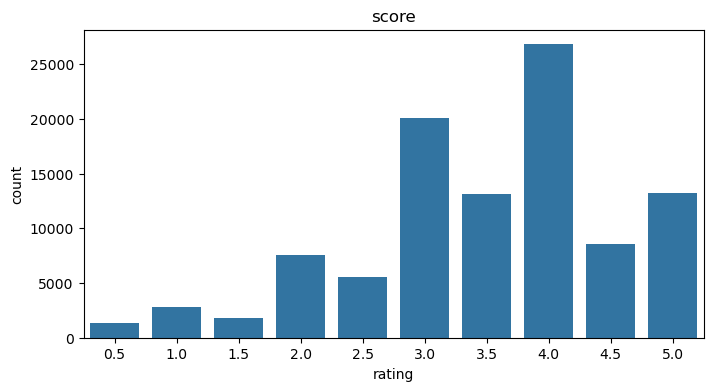

In [5]:
plt.figure(figsize=(8,4))
sns.countplot(x=ratings['rating'])
plt.title("score")
plt.show()
#ازین نمودار می فهمیم بیشتر کاربران چه امتیازیی داده اند

In [6]:
movie_rating_count = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
movie_rating_mean = ratings.groupby('movieId')['rating'].mean()

print(movie_rating_count.head())
print(movie_rating_mean.head())
#میانگین و ریتینگ هر فیلم بطور کلی

movieId
356     329
318     317
296     307
593     279
2571    278
Name: rating, dtype: int64
movieId
1    3.920930
2    3.431818
3    3.259615
4    2.357143
5    3.071429
Name: rating, dtype: float64


جدا کردن داده ها بصورت هشتاد بیست

In [24]:
def train_test_split_per_user(df, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_rows = []
    test_rows = []

    for user_id, user_df in df.groupby("userId"):
        n = len(user_df)
        n_test = int(np.floor(n * test_size))
        indices = np.arange(n)
        rng.shuffle(indices)

        test_idx = indices[:n_test]
        train_idx = indices[n_test:]

        test_rows.append(user_df.iloc[test_idx])
        train_rows.append(user_df.iloc[train_idx])

    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = train_test_split_per_user(ratings, test_size=0.2)
print("train:", train_df.shape, "test:", test_df.shape)


train: (80896, 4) test: (19940, 4)


یک ماتریکش میسازیم که شکل استاندارد داده های ریتینگ را به مدلی تبدیل میکند که الگوریتم بتواند روی ان محاسبه انجام دهد

In [26]:
user_movie_matrix = train_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)  
user_means = user_movie_matrix.mean(axis=1)
ratings_demeaned = user_movie_matrix.sub(user_means, axis=0)
ratings_demeaned_filled = ratings_demeaned.fillna(0)
user_movie_matrix.head()


movieId,1,2,3,4,5,6,7,8,9,10,...,190219,190221,191005,193565,193571,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### درست کردن
### User Similarity Matrix
### که می اید طبق ماتریس قبلی شباهت بین کاربران را میفهمد و پیدا میکند

In [38]:
user_similarity = cosine_similarity(ratings_demeaned_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)


# این کد دو ماتریس بالا را بر هم تقسیم میکند و سه کار انجام می دهد
## کاربران مشابه پیدا می‌شوند
## امتیازهای آنها به فیلم استفاده می‌شود
## میانگین وزن‌دار گرفته می‌شود 

In [39]:
ratings_matrix = user_movie_matrix.values


predicted_ratings = np.dot(user_similarity, ratings_matrix) / np.abs(user_similarity).sum(axis=1).reshape(-1,1)
predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)
predicted_ratings_df.head()


movieId,1,2,3,4,5,6,7,8,9,10,...,190219,190221,191005,193565,193571,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:

ratings_matrix = ratings_demeaned_filled.values

denominator = np.abs(user_similarity).sum(axis=1).reshape(-1,1)
denominator[denominator == 0] = 1

predicted_ratings = np.dot(user_similarity, ratings_matrix) / denominator

predicted_ratings = predicted_ratings + user_means.values.reshape(-1,1)

predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)

print("Prediction matrix shape:", predicted_ratings_df.shape)


y_true = []
y_pred = []

for row in test_df.itertuples():

    user = row.userId
    movie = row.movieId
    true_rating = row.rating

    if user in predicted_ratings_df.index and movie in predicted_ratings_df.columns:

        pred_rating = predicted_ratings_df.loc[user, movie]

        if not np.isnan(pred_rating):
            y_true.append(true_rating)
            y_pred.append(pred_rating)


print("Number of predictions:", len(y_pred))

if len(y_pred) > 0:

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print("RMSE:", rmse)
    print("MAE:", mae)

else:
    print("No valid predictions were made.")



Prediction matrix shape: (610, 8990)
Number of predictions: 19152
RMSE: 0.9231876470130964
MAE: 0.7160227952780683
